In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

In [2]:
train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv', parse_dates=['event_ts'])

## Удаление одинаковых строк в events

In [3]:
print('Размер до удаления:', events.shape)
print('Полных дубликатов:', events.duplicated().sum())
events = events.drop_duplicates().reset_index(drop=True)
print('Размер после удаления:', events.shape)

Размер до удаления: (328905, 14)
Полных дубликатов: 4863
Размер после удаления: (324042, 14)


## Оставляет только те cookie_id, которые попали во временное окно и формируем DataFrame для обучения и теста 

In [4]:
def events_in_window(events, meta):
    if "target" in meta.columns:
        ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts', "target"]], on='cookie_id')
    else:
        ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

195484 88349


## Так как все платформы написаны в разных регистрах, необходимо приввести все значения к одному регистру

In [5]:
print(ev_tr["platform"].value_counts())
ev_tr["platform"] = ev_tr["platform"].str.lower()
print("\n")
print(ev_tr["platform"].value_counts())

platform
desktop    27439
Web        27070
WEB        27019
web        26854
ANDROID    25803
android    25517
Android    25506
IOS         2594
iOS         2588
iphone      2561
ios         2533
Name: count, dtype: int64


platform
web        80943
android    76826
desktop    27439
ios         7715
iphone      2561
Name: count, dtype: int64


<Axes: xlabel='platform', ylabel='Probability'>

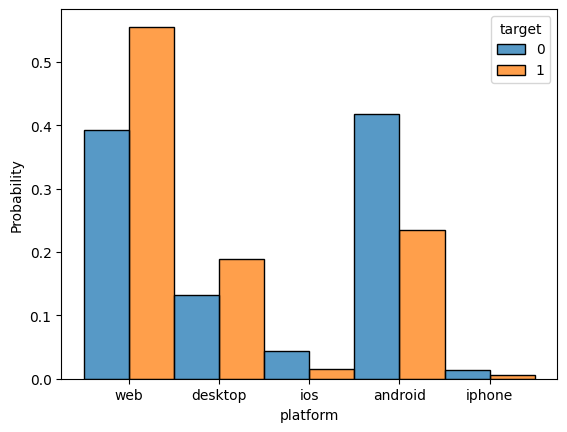

In [6]:
sns.histplot(data=ev_tr, x='platform', hue='target',
             multiple='dodge', stat='probability', common_norm=False) 

<Axes: xlabel='Probability', ylabel='event_name'>

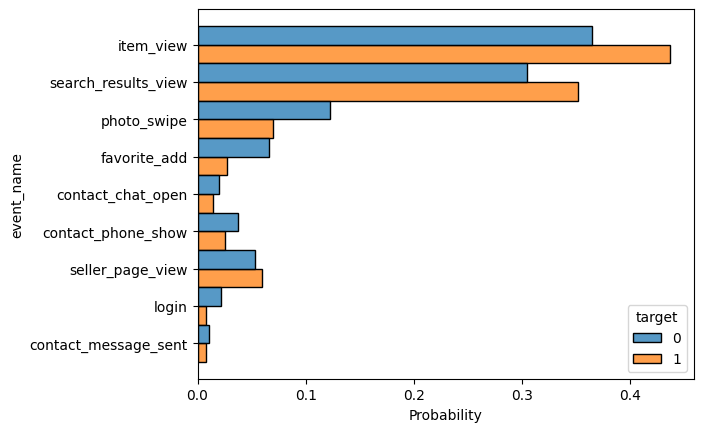

In [7]:
sns.histplot(data=ev_tr, y='event_name', hue='target',
             multiple='dodge', stat='probability', common_norm=False) 

### Признаки последовательности событий

Считаются по порядку действий внутри куки (сортировка по времени).

- `self_repeat_rate` — доля самоповторов подряд (высокая у ботов).
- `bigram_entropy` — энтропия пар последовательных событий (низкая у ботов).
- `bigram_nunique` — число уникальных биграмм.
- `event_entropy` — энтропия типов событий.
- `n_event_types` — число уникальных типов событий.

**Идея:** бот действует шаблонно — повторяет одни и те же действия в одном порядке.
Человек чередует поиск, просмотр, избранное и контакты.

from collections import Counter

def build_seq_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.sort_values(['cookie_id', 'event_ts']).copy()

    ev['is_repeat'] = (
        ev.groupby('cookie_id')['event_name'].shift() == ev['event_name']
    ).astype(int)
    self_repeat = ev.groupby('cookie_id')['is_repeat'].mean().rename('self_repeat_rate')

    def bigram_entropy(x):
        if len(x) < 2:
            return np.nan
        bigrams = list(zip(x[:-1], x[1:]))
        counts = Counter(bigrams)
        total = sum(counts.values())
        p = np.array(list(counts.values())) / total
        return -(p * np.log(p)).sum()

    bigram_ent = ev.groupby('cookie_id')['event_name'].apply(bigram_entropy).rename('bigram_entropy')

    bigram_nunique = ev.groupby('cookie_id')['event_name'].apply(
        lambda x: len(set(zip(x[:-1], x[1:])))
    ).rename('bigram_nunique')

    def entropy(counts):
        p = counts / counts.sum()
        p = p[p > 0]
        return -(p * np.log(p)).sum()

    event_entropy = ev.groupby('cookie_id')['event_name'].apply(
        lambda x: entropy(x.value_counts())
    ).rename('event_entropy')

    event_nunique = ev.groupby('cookie_id')['event_name'].nunique().rename('n_event_types')

    seq_features = pd.concat([
        self_repeat,
        bigram_ent,
        bigram_nunique,
        event_entropy,
        event_nunique,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        seq_features = seq_features.merge(targets, on='cookie_id', how='left')

    return seq_features

seq_features = build_seq_features(ev_tr)
seq_features_test = build_seq_features(ev_te)

### Признаки курсора

Считаются по `pointer_x` / `pointer_y` внутри каждой куки.

- `cursor_missing_rate` — доля событий без координат там, где они ожидаются.
- `pointer_x_mean`, `pointer_x_std` — среднее и разброс по X.
- `pointer_y_mean`, `pointer_y_std` — среднее и разброс по Y.
- `x_unique_share` — доля уникальных X.
- `xy_pair_unique_share` — доля уникальных пар (X, Y).
- `move_dist_mean`, `move_dist_std` — средняя и σ длины перемещения между точками.
- `zero_move_rate` — доля нулевых перемещений.

**Идея:** живой пользователь двигает курсор — много уникальных координат,
ненулевые перемещения, большой разброс. Бот либо не передаёт координаты
(`cursor_missing_rate = 1`), либо кликает в одну точку
(`zero_move_rate ≈ 1`, `x_unique_share ≈ 0`).

In [9]:
def build_cursor_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.sort_values(['cookie_id', 'event_ts']).copy()

    expected_events = ['item_view', 'photo_swipe', 'favorite_add',
                       'contact_chat_open', 'search_results_view']

    expected = ev[ev['event_name'].isin(expected_events)]

    no_coords = (
        expected.assign(no_coord=(expected['pointer_x'].isna() |
                                  expected['pointer_y'].isna()).astype(int))
        .groupby('cookie_id')['no_coord']
        .mean()
        .rename('cursor_missing_rate')
    )

    cursor_stats = ev.groupby('cookie_id').agg(
        pointer_x_mean=('pointer_x', 'mean'),
        pointer_x_std=('pointer_x', 'std'),
        pointer_y_mean=('pointer_y', 'mean'),
        pointer_y_std=('pointer_y', 'std'),
    )

    ev_valid = ev[ev['pointer_x'].notna() & ev['pointer_y'].notna()].copy()

    ev_valid['x_round'] = ev_valid['pointer_x'].round(3)
    ev_valid['y_round'] = ev_valid['pointer_y'].round(3)

    unique_stats = ev_valid.groupby('cookie_id').agg(
        x_unique=('x_round', 'nunique'),
        n_valid=('x_round', 'size'),
    )
    unique_stats['x_unique_share'] = unique_stats['x_unique'] / unique_stats['n_valid']

    pair_unique = ev_valid.groupby('cookie_id').apply(
        lambda g: len(set(zip(g['x_round'], g['y_round']))) / len(g)
    ).rename('xy_pair_unique_share')

    ev_valid = ev_valid.sort_values(['cookie_id', 'event_ts']).copy()
    ev_valid['dx'] = ev_valid.groupby('cookie_id')['pointer_x'].diff()
    ev_valid['dy'] = ev_valid.groupby('cookie_id')['pointer_y'].diff()
    ev_valid['move_dist'] = np.sqrt(ev_valid['dx']**2 + ev_valid['dy']**2)

    move_stats = ev_valid.groupby('cookie_id')['move_dist'].agg(
        move_dist_mean='mean',
        move_dist_std='std',
    )

    zero_move = ev_valid.groupby('cookie_id')['move_dist'].apply(
        lambda x: (x.dropna() == 0).mean()
    ).rename('zero_move_rate')

    cursor_features = pd.concat([
        no_coords,
        cursor_stats,
        unique_stats[['x_unique_share']],
        pair_unique,
        move_stats,
        zero_move,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        cursor_features = cursor_features.merge(targets, on='cookie_id', how='left')

    return cursor_features

cursor_features = build_cursor_features(ev_tr)
cursor_features_test = build_cursor_features(ev_te)

C:\Users\Даниил\AppData\Local\Temp\ipykernel_5884\3775587083.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pair_unique = ev_valid.groupby('cookie_id').apply(
C:\Users\Даниил\AppData\Local\Temp\ipykernel_5884\3775587083.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pair_unique = ev_valid.groupby('cookie_id').apply(


### Признаки времени суток

- `night_share` — доля событий ночью (0:00–5:59).
- `workday_share` — доля в рабочие часы (9:00–17:59).
- `evening_share` — доля вечером (18:00–23:59).
- `hours_nunique` — число разных часов суток, в которые была активность.
- `hours_entropy` — энтропия распределения по часам.
- `hours_coverage` — доля часов из 24, в которые кука была активна.

**Идея:** человек спит ночью и активен днём/вечером. Бот работает 24/7 —
высокая ночная доля, много разных часов, энтропия близка к `log(24)`,
покрытие ≈ 1.

In [10]:
import numpy as np
import pandas as pd


def build_time_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.copy()
    ev['event_ts'] = pd.to_datetime(ev['event_ts'])
    ev['hour'] = ev['event_ts'].dt.hour

    ev['is_night'] = ev['hour'].between(0, 5).astype(int)
    ev['is_workday'] = ev['hour'].between(9, 17).astype(int)
    ev['is_evening'] = ev['hour'].between(18, 23).astype(int)

    time_share = ev.groupby('cookie_id').agg(
        night_share=('is_night', 'mean'),
        workday_share=('is_workday', 'mean'),
        evening_share=('is_evening', 'mean'),
    )

    hours_nunique = (
        ev.groupby('cookie_id')['hour']
        .nunique()
        .rename('hours_nunique')
    )

    def entropy(counts):
        p = counts / counts.sum()
        p = p[p > 0]
        return -(p * np.log(p)).sum()

    hours_entropy = (
        ev.groupby('cookie_id')['hour']
        .apply(lambda x: entropy(x.value_counts()))
        .rename('hours_entropy')
    )

    hours_coverage = (
        ev.groupby('cookie_id')['hour']
        .nunique()
        .div(24)
        .rename('hours_coverage')
    )

    time_features = pd.concat([
        time_share,
        hours_nunique,
        hours_entropy,
        hours_coverage,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        time_features = time_features.merge(targets, on='cookie_id', how='left')

    return time_features

time_features = build_time_features(ev_tr)
time_features_test = build_time_features(ev_te)

## Признаки таймингов интервалов

Считаются по интервалам `dt` между соседними событиями внутри куки
(`event_ts.diff()` в секундах). Идея: бот кликает быстро и шаблонно,
человек — медленно и хаотично.

### 28 признаков

- **Базовые (8):** `dt_median`, `dt_mean`, `dt_std`, `dt_min`, `dt_max`, `dt_q10`, `dt_q90`, `dt_iqr`.
- **Производные (2):** `dt_cv` (σ/μ), `dt_burstiness` = (σ − μ)/(σ + μ). `> 0` — всплески.
- **Log-интервалы (3):** `log_dt_mean`, `log_dt_std`, `log_dt_median` — устойчивы к выбросам.
- **7 порогов:** `dt_short_share_{1,2,5,10,30,60,300}` — доля интервалов короче X сек.
- **Энтропия и мода (2):** `dt_entropy`, `dt_mode_share` (доля самой частой задержки).
- **Регулярность (2):** `dt_diff_median` (медиана |dt_i − dt_{i−1}|), `dt_diff_median_ratio`.


**Логика:** бот действует машинально — минимальные паузы, фиксированные задержки,
всплески. Человек думает и отвлекается — интервалы длиннее и разнообразнее.

In [11]:
def build_timing_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.sort_values(['cookie_id', 'event_ts']).copy()
    ev['event_ts'] = pd.to_datetime(ev['event_ts'])

    ev['dt'] = ev.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

    dt_df = ev[ev['dt'].notna()].copy()

    basic = dt_df.groupby('cookie_id')['dt'].agg(
        dt_median='median',
        dt_mean='mean',
        dt_std='std',
        dt_min='min',
        dt_max='max',
        dt_q10=lambda x: x.quantile(0.10),
        dt_q90=lambda x: x.quantile(0.90),
    )

    iqr = dt_df.groupby('cookie_id')['dt'].apply(
        lambda x: x.quantile(0.75) - x.quantile(0.25)
    ).rename('dt_iqr')

    cv = (basic['dt_std'] / (basic['dt_mean'] + 1e-6)).rename('dt_cv')

    burstiness = (
        (basic['dt_std'] - basic['dt_mean']) /
        (basic['dt_std'] + basic['dt_mean'] + 1e-6)
    ).rename('dt_burstiness')

    dt_df['log_dt'] = np.log1p(dt_df['dt'])

    log_stats = dt_df.groupby('cookie_id')['log_dt'].agg(
        log_dt_mean='mean',
        log_dt_std='std',
        log_dt_median='median',
    )

    thresholds = [1, 2, 5, 10, 30, 60, 300]

    threshold_feats = pd.DataFrame(index=basic.index)
    for t in thresholds:
        threshold_feats[f'dt_short_share_{t}'] = dt_df.groupby('cookie_id')['dt'].apply(
            lambda x: (x <= t).mean()
        )

    def entropy(counts):
        p = counts / counts.sum()
        p = p[p > 0]
        return -(p * np.log(p)).sum()

    def mode_share(x, decimals=0):
        x = x.dropna().round(decimals)
        if len(x) == 0:
            return np.nan
        return x.value_counts(normalize=True).iloc[0]

    dt_entropy = dt_df.groupby('cookie_id')['dt'].apply(
        lambda x: entropy(x.round().value_counts())
    ).rename('dt_entropy')

    dt_mode_share = dt_df.groupby('cookie_id')['dt'].apply(
        lambda x: mode_share(x)
    ).rename('dt_mode_share')

    dt_df['dt_diff_abs'] = dt_df.groupby('cookie_id')['dt'].diff().abs()

    dt_diff_median = dt_df.groupby('cookie_id')['dt_diff_abs'].median().rename('dt_diff_median')

    dt_diff_ratio = (
        dt_diff_median / (basic['dt_median'] + 1e-6)
    ).rename('dt_diff_median_ratio')

    timing_features = pd.concat([
        basic,
        iqr,
        cv,
        burstiness,
        log_stats,
        threshold_feats,
        dt_entropy,
        dt_mode_share,
        dt_diff_median,
        dt_diff_ratio,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        timing_features = timing_features.merge(targets, on='cookie_id', how='left')

    return timing_features

timing_features = build_timing_features(ev_tr)
timing_features_test = build_timing_features(ev_te)

## Признаки состава событий

Считаются по `event_name` внутри каждой куки. Идея: бот смотрит много,
а взаимодействует мало — профиль действий резко перекошен в сторону просмотров.

### 30 признаков

- **9 счётчиков:** `cnt_item_view`, `cnt_search_results_view`, `cnt_photo_swipe`,
  `cnt_favorite_add`, `cnt_contact_chat_open`, `cnt_contact_phone_show`,
  `cnt_seller_page_view`, `cnt_login`, `cnt_contact_message_sent`.
- **9 долей:** `share_*` — то же, нормированное на все события.
- **1 агрегат контактов:** `contact_events_total` (чат + телефон + сообщение).
- **5 отношений:**
  - `swipe_per_view`, `fav_per_view`, `contact_per_view`, `seller_per_view`, `view_per_search`.
- **9 флагов:** `has_*` — 1, если действие встречалось хотя бы раз.
- **1 доля пассива:** `passive_share` — доля просмотров/свайпов среди всех действий.


**Логика:** бот — пассивный наблюдатель: много просмотров, огромное
`view_per_search`, почти нулевые контакты и избранное, `passive_share → 1`.
Человек — разнообразный профиль с реакцией на товары.

In [12]:
def build_event_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.copy()

    event_counts = (
        ev.groupby(['cookie_id', 'event_name'])
        .size()
        .unstack(fill_value=0)
        .add_prefix('cnt_')
    )

    event_share = (
        event_counts
        .div(event_counts.sum(axis=1), axis=0)
        .add_prefix('share_')
    )
    event_share.columns = [c.replace('share_cnt_', 'share_') for c in event_share.columns]

    contact_cols = [c for c in event_counts.columns
                    if any(k in c for k in ['contact_chat_open',
                                            'contact_phone_show',
                                            'contact_message_sent'])]

    if contact_cols:
        contact_total = event_counts[contact_cols].sum(axis=1).rename('contact_events_total')
    else:
        contact_total = pd.Series(0, index=event_counts.index, name='contact_events_total')

    n_events = event_counts.sum(axis=1)

    ratios = pd.DataFrame(index=event_counts.index)

    if 'cnt_photo_swipe' in event_counts.columns and 'cnt_item_view' in event_counts.columns:
        ratios['swipe_per_view'] = event_counts['cnt_photo_swipe'] / (event_counts['cnt_item_view'] + 1)

    if 'cnt_favorite_add' in event_counts.columns and 'cnt_item_view' in event_counts.columns:
        ratios['fav_per_view'] = event_counts['cnt_favorite_add'] / (event_counts['cnt_item_view'] + 1)

    ratios['contact_per_view'] = contact_total / (event_counts.get('cnt_item_view', 0) + 1)

    if 'cnt_seller_page_view' in event_counts.columns and 'cnt_item_view' in event_counts.columns:
        ratios['seller_per_view'] = event_counts['cnt_seller_page_view'] / (event_counts['cnt_item_view'] + 1)

    if 'cnt_item_view' in event_counts.columns and 'cnt_search_results_view' in event_counts.columns:
        ratios['view_per_search'] = event_counts['cnt_item_view'] / (event_counts['cnt_search_results_view'] + 1)

    event_flags = (
        (event_counts > 0)
        .astype(int)
        .add_prefix('has_')
    )
    event_flags.columns = [c.replace('has_cnt_', 'has_') for c in event_flags.columns]

    passive_cols = [c for c in event_counts.columns
                    if any(k in c for k in ['item_view', 'search_results_view',
                                            'photo_swipe'])]

    passive_total = event_counts[passive_cols].sum(axis=1).rename('passive_events_total')
    passive_share = (passive_total / (n_events + 1e-6)).rename('passive_share')

    event_features = pd.concat([
        event_counts,
        event_share,
        contact_total,
        ratios,
        event_flags,
        passive_share,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        event_features = event_features.merge(targets, on='cookie_id', how='left')

    return event_features

event_features = build_event_features(ev_tr)
event_features_test = build_event_features(ev_te)

## Признаки поискового поведения

Считаются по страницам выдачи (`search_page`) внутри каждой куки.
Идея: бот листает поиск глубоко, методично и без возвратов — человек
смотрит 1–2 страницы и уходит.

### 8 признаков

- `max_search_page` — максимальная страница выдачи.
- `mean_search_page` — средняя страница.
- `std_search_page` — разброс страниц.
- `deep_page_share` — доля страниц ≥ 3.
- `next_page_share` — доля переходов ровно +1 (методичный парсинг).
- `back_page_share` — доля возвратов назад (page_diff < 0).
- `queries_nunique` — число уникальных `search_query`.
- `sum_pages` — сумма всех страниц за всё время.


**Логика:** бот обходит пагинацию последовательно и глубоко, без возвратов,
с большим числом запросов. Человек — поверхностно, с возвратами, малым числом
запросов.

In [13]:
def build_search_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.copy()
    ev['event_ts'] = pd.to_datetime(ev['event_ts'])
    ev = ev.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

    search_ev = ev[ev['search_page'].notna()].copy()

    search_ev['search_page'] = pd.to_numeric(search_ev['search_page'], errors='coerce')
    search_ev = search_ev[search_ev['search_page'].notna()].copy()

    page_stats = search_ev.groupby('cookie_id')['search_page'].agg(
        max_search_page='max',
        mean_search_page='mean',
        std_search_page='std',
    )

    DEEP_THRESHOLD = 3
    deep_share = search_ev.groupby('cookie_id')['search_page'].apply(
        lambda x: (x >= DEEP_THRESHOLD).mean()
    ).rename('deep_page_share')

    search_ev['page_diff'] = search_ev.groupby('cookie_id')['search_page'].diff()

    next_step = search_ev.groupby('cookie_id')['page_diff'].apply(
        lambda x: (x.dropna() == 1).mean()
    ).rename('next_page_share')

    back_step = search_ev.groupby('cookie_id')['page_diff'].apply(
        lambda x: (x.dropna() < 0).mean()
    ).rename('back_page_share')

    if 'search_query' in search_ev.columns:
        queries_per_search = search_ev.groupby('cookie_id')['search_query'].nunique().rename('queries_nunique')
    else:
        queries_per_search = search_ev.groupby('cookie_id').size().rename('queries_nunique')

    sum_pages = search_ev.groupby('cookie_id')['search_page'].sum().rename('sum_pages')

    search_features = pd.concat([
        page_stats,
        deep_share,
        next_step,
        back_step,
        queries_per_search,
        sum_pages,
    ], axis=1).reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        search_features = search_features.merge(targets, on='cookie_id', how='left')

    search_features['std_search_page'] = search_features['std_search_page'].fillna(0)
    search_features['next_page_share'] = search_features['next_page_share'].fillna(0)
    search_features['back_page_share'] = search_features['back_page_share'].fillna(0)

    return search_features

search_features = build_search_features(ev_tr)
search_features_test = build_search_features(ev_te)

## Признаки User-Agent

Считаются по `user_agent`. Идея: боты используют
headless-браузеры и скрипты, а живые люди — обычные браузеры на мобильных
или десктопных ОС.

### 12 признаков

- `is_headless` — есть ли в UA `HeadlessChrome`, `PhantomJS`, `Selenium`,
  `Puppeteer`, `python-requests`, `curl`, `wget`. **Самый сильный признак.**
- `is_bot_marker` — есть ли слова `bot`, `crawler`, `spider` (с границами слов).
- `strange_word` — агрегированный флаг: `is_headless` ИЛИ `is_bot_marker`.
- `is_mobile` — `Mobile`, `Android`, `iPhone` в UA.
- `is_android`, `is_ios`, `is_windows`, `is_mac`, `is_linux` — тип ОС.
- `is_chrome`, `is_firefox`, `is_safari` — тип браузера.


**Логика:** бот сидит на headless-браузере (обычно Linux + десктоп),
человек — на мобильном устройстве или обычном десктопе.

In [14]:
import numpy as np
import pandas as pd


def build_ua_features(ev_input: pd.DataFrame) -> pd.DataFrame:
    ev = ev_input.copy()

    ua = ev.groupby('cookie_id')['user_agent'].first().str.lower()

    ua_features = pd.DataFrame(index=ua.index)

    ua_features['is_headless'] = ua.str.contains(
        'headless|phantomjs|selenium|puppeteer|python-requests|curl|wget',
        na=False, regex=True
    ).astype(int)

    ua_features['is_bot_marker'] = ua.str.contains(
        r'\b(bot|crawler|spider)\b', na=False, regex=True
    ).astype(int)

    ua_features['is_mobile'] = ua.str.contains(
        'mobile|android|iphone', na=False, regex=True
    ).astype(int)

    ua_features['is_android'] = ua.str.contains('android', na=False).astype(int)
    ua_features['is_ios']     = ua.str.contains('iphone|ipad|ios', na=False).astype(int)
    ua_features['is_windows'] = ua.str.contains('windows', na=False).astype(int)
    ua_features['is_mac']     = ua.str.contains('macintosh|mac os', na=False).astype(int)
    ua_features['is_linux']   = ua.str.contains('linux|x11', na=False).astype(int)

    ua_features['is_chrome']  = ua.str.contains('chrome', na=False).astype(int)
    ua_features['is_firefox'] = ua.str.contains('firefox', na=False).astype(int)
    ua_features['is_safari']  = ua.str.contains('safari', na=False).astype(int)

    ua_features['strange_word'] = (
        (ua_features['is_headless'] == 1) | (ua_features['is_bot_marker'] == 1)
    ).astype(int)

    ua_features = ua_features.reset_index()

    if 'target' in ev.columns:
        targets = ev.groupby('cookie_id')['target'].first().reset_index()
        ua_features = ua_features.merge(targets, on='cookie_id', how='left')

    return ua_features

ua_features = build_ua_features(ev_tr)
ua_features_test = build_ua_features(ev_te)

C:\Users\Даниил\AppData\Local\Temp\ipykernel_5884\454594261.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ua_features['is_bot_marker'] = ua.str.contains(
C:\Users\Даниил\AppData\Local\Temp\ipykernel_5884\454594261.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ua_features['is_bot_marker'] = ua.str.contains(


## Объединение всех признаков в один DataFrame для обучения

In [19]:
def merge_features(df_with_feature, feature):
    if "target" in feature.columns:
        cols = feature.drop(columns=["target"]).columns
    else:
        cols = feature.columns
        
    return df_with_feature.merge(
        feature[cols],
        on='cookie_id',
        how='left'
    )

def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g['item_id'].nunique(),
    }).reset_index()

    #Присоединяем к meta — все cookie_id из meta сохраняются
    result = meta.merge(f, on='cookie_id', how='left')
    return result

df_with_feature = train[['cookie_id', "target"]]

df_with_feature = merge_features(df_with_feature, seq_features)
df_with_feature = merge_features(df_with_feature, cursor_features)
df_with_feature = merge_features(df_with_feature, time_features)
df_with_feature = merge_features(df_with_feature, timing_features)
df_with_feature = merge_features(df_with_feature, event_features)
df_with_feature = merge_features(df_with_feature, event_features)
df_with_feature = merge_features(df_with_feature, ua_features)

df_with_feature = basic_features(ev_tr, df_with_feature)

df_with_feature

,cookie_id,target,self_repeat_rate,bigram_entropy,bigram_nunique,event_entropy,n_event_types,cursor_missing_rate,pointer_x_mean,pointer_x_std,...,is_ios,is_windows,is_mac,is_linux,is_chrome,is_firefox,is_safari,strange_word,n_events,item_nunique
0,ck_54a059eb7d3ea68b,0,0.285714,1.560710,5,1.004242,3,1.000000,NaN,NaN,...,0,0,0,0,0,0,0,0,7,4
1,ck_7e4de46eeab82974,0,0.414634,2.335282,18,1.378723,7,0.085714,917.868421,509.231969,...,0,1,0,0,1,0,1,0,41,19
2,ck_9320229ef6304522,0,0.138889,3.020247,23,1.874204,9,0.037037,936.457143,602.124295,...,0,1,0,0,1,0,1,0,36,19
3,ck_30ccd25bc1714ed9,0,0.428571,1.799037,9,1.062192,5,1.000000,NaN,NaN,...,0,1,0,0,1,0,1,0,21,10
4,ck_a77c5f05948cdeef,0,0.250000,2.640947,16,1.518035,6,0.041667,978.000000,450.561957,...,0,0,1,0,1,0,1,0,28,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11086,ck_2256c19bb847dd0e,0,0.285714,1.560710,5,1.153742,4,1.000000,NaN,NaN,...,0,0,0,0,0,0,0,0,7,2
11087,ck_ba2e403201cba06d,0,0.333333,1.609438,5,1.329661,4,1.000000,NaN,NaN,...,0,0,0,0,0,0,0,0,6,2
11088,ck_2f43054a1f52b9a2,0,0.150000,2.798513,17,1.733984,7,0.142857,965.388889,580.939314,...,0,0,1,0,1,0,1,0,20,13
11089,ck_354f57a870e41ddd,0,0.333333,1.609438,5,1.329661,4,1.000000,NaN,NaN,...,0,0,0,0,0,0,0,0,6,1


In [21]:
print(train.index.equals(df_with_feature.index))

True


In [22]:
is_valid = train.window_start_ts.ge('2026-04-17').values
x = df_with_feature.drop(columns=["target", "cookie_id"])
y = df_with_feature["target"]
X_train, y_train = x[~is_valid], y[~is_valid]
X_valid, y_valid = x[is_valid],  y[is_valid]

In [23]:
X_train.columns

Index(['self_repeat_rate', 'bigram_entropy', 'bigram_nunique', 'event_entropy',
       'n_event_types', 'cursor_missing_rate', 'pointer_x_mean',
       'pointer_x_std', 'pointer_y_mean', 'pointer_y_std',
       ...
       'is_ios', 'is_windows', 'is_mac', 'is_linux', 'is_chrome', 'is_firefox',
       'is_safari', 'strange_word', 'n_events', 'item_nunique'],
      dtype='object', length=127)

## Обучение модели 

In [24]:
model = CatBoostClassifier(
    #cat_features=["main_platform"],
    iterations=3000,
    random_strength=3,
    auto_class_weights='Balanced',
    eval_metric='PRAUC',
    random_state=0,
    verbose=100,
    early_stopping_rounds=500,
    depth=5,                    
    l2_leaf_reg=14,
    learning_rate=0.03,
)

model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

0:	learn: 0.7810231	test: 0.7729372	best: 0.7729372 (0)	total: 141ms	remaining: 7m 3s
100:	learn: 0.9278625	test: 0.9109919	best: 0.9109919 (100)	total: 619ms	remaining: 17.8s
200:	learn: 0.9427212	test: 0.9192534	best: 0.9192991 (199)	total: 1.1s	remaining: 15.3s
300:	learn: 0.9521892	test: 0.9225862	best: 0.9225862 (300)	total: 1.56s	remaining: 14s
400:	learn: 0.9660823	test: 0.9297562	best: 0.9297729 (399)	total: 2.05s	remaining: 13.3s
500:	learn: 0.9763629	test: 0.9326034	best: 0.9326034 (500)	total: 2.52s	remaining: 12.6s
600:	learn: 0.9832315	test: 0.9340073	best: 0.9340707 (596)	total: 3.01s	remaining: 12s
700:	learn: 0.9881743	test: 0.9336452	best: 0.9341717 (636)	total: 3.5s	remaining: 11.5s
800:	learn: 0.9911362	test: 0.9326608	best: 0.9341717 (636)	total: 3.98s	remaining: 10.9s
900:	learn: 0.9933936	test: 0.9323260	best: 0.9341717 (636)	total: 4.46s	remaining: 10.4s
1000:	learn: 0.9947668	test: 0.9325577	best: 0.9341717 (636)	total: 4.93s	remaining: 9.86s
1100:	learn: 0.9959

CatBoostClassifier(auto_class_weights='Balanced', depth=5, early_stopping_rounds=500, eval_metric='PRAUC', iterations=3000, l2_leaf_reg=14, learning_rate=0.03, random_state=0, random_strength=3, verbose=100)

In [ ]:
from metric import precision_at_recall


predict = model.predict_proba(X_valid)[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(y_valid, predict), 4))

In [ ]:
model.get_feature_importance(prettified=True)

## Формирование ответа

In [27]:
df_test_with_feature = test[['cookie_id']]

df_test_with_feature = merge_features(df_test_with_feature, seq_features_test)
df_test_with_feature = merge_features(df_test_with_feature, cursor_features_test)
df_test_with_feature = merge_features(df_test_with_feature, time_features_test)
df_test_with_feature = merge_features(df_test_with_feature, timing_features_test)
df_test_with_feature = merge_features(df_test_with_feature, event_features_test)
df_test_with_feature = merge_features(df_test_with_feature, ua_features_test)

df_test_with_feature = basic_features(ev_te, df_test_with_feature)

df_test_with_feature

X = df_with_feature.drop(columns=["target", "cookie_id"])
y = df_with_feature["target"]

model.fit(X, y)

X_test = df_test_with_feature[X.columns]   # ← тот же порядок и набор колонок

sub = pd.DataFrame({
    'cookie_id': df_test_with_feature['cookie_id'],
    'score': model.predict_proba(X_test)[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

0:	learn: 0.7896045	total: 7.64ms	remaining: 22.9s
100:	learn: 0.9242003	total: 635ms	remaining: 18.2s
200:	learn: 0.9405178	total: 1.27s	remaining: 17.7s
300:	learn: 0.9497227	total: 1.9s	remaining: 17s
400:	learn: 0.9613650	total: 2.52s	remaining: 16.3s
500:	learn: 0.9719945	total: 3.16s	remaining: 15.8s
600:	learn: 0.9790853	total: 3.77s	remaining: 15.1s
700:	learn: 0.9842230	total: 4.4s	remaining: 14.4s
800:	learn: 0.9877841	total: 5.01s	remaining: 13.8s
900:	learn: 0.9903780	total: 5.62s	remaining: 13.1s
1000:	learn: 0.9920329	total: 6.23s	remaining: 12.4s
1100:	learn: 0.9935926	total: 6.83s	remaining: 11.8s
1200:	learn: 0.9947461	total: 7.44s	remaining: 11.1s
1300:	learn: 0.9956987	total: 8.05s	remaining: 10.5s
1400:	learn: 0.9964711	total: 8.66s	remaining: 9.89s
1500:	learn: 0.9970827	total: 9.29s	remaining: 9.28s
1600:	learn: 0.9975653	total: 9.91s	remaining: 8.66s
1700:	learn: 0.9979579	total: 10.5s	remaining: 8.05s
1800:	learn: 0.9982960	total: 11.2s	remaining: 7.45s
1900:	le

KeyError: "['cnt_contact_chat_open_x', 'cnt_contact_message_sent_x', 'cnt_contact_phone_show_x', 'cnt_favorite_add_x', 'cnt_item_view_x', 'cnt_login_x', 'cnt_photo_swipe_x', 'cnt_search_results_view_x', 'cnt_seller_page_view_x', 'share_contact_chat_open_x', 'share_contact_message_sent_x', 'share_contact_phone_show_x', 'share_favorite_add_x', 'share_item_view_x', 'share_login_x', 'share_photo_swipe_x', 'share_search_results_view_x', 'share_seller_page_view_x', 'contact_events_total_x', 'swipe_per_view_x', 'fav_per_view_x', 'contact_per_view_x', 'seller_per_view_x', 'view_per_search_x', 'has_contact_chat_open_x', 'has_contact_message_sent_x', 'has_contact_phone_show_x', 'has_favorite_add_x', 'has_item_view_x', 'has_login_x', 'has_photo_swipe_x', 'has_search_results_view_x', 'has_seller_page_view_x', 'passive_share_x', 'cnt_contact_chat_open_y', 'cnt_contact_message_sent_y', 'cnt_contact_phone_show_y', 'cnt_favorite_add_y', 'cnt_item_view_y', 'cnt_login_y', 'cnt_photo_swipe_y', 'cnt_searc

## Ниже закомментировал поиск по сетке 

In [17]:
# from catboost import CatBoostClassifier
# from metric import precision_at_recall
# import pandas as pd
# import time

# # Сетка параметров
# depths = [3, 4, 5]
# l2_regs = [5, 8, 12, 14]
# learning_rates = [0.02, 0.03, 0.05]
# random_strengths = [1, 3, 5]

# results = []
# total = len(depths) * len(l2_regs) * len(learning_rates) * len(random_strengths)
# i = 0

# for depth in depths:
#     for l2 in l2_regs:
#         for lr in learning_rates:
#             for rs in random_strengths:
#                 i += 1
#                 t0 = time.time()

#                 model = CatBoostClassifier(
#                     iterations=3000,
#                     depth=depth,
#                     l2_leaf_reg=l2,
#                     learning_rate=lr,
#                     random_strength=rs,
#                     auto_class_weights='Balanced',
#                     eval_metric='PRAUC',
#                     random_state=0,
#                     verbose=0,
#                     early_stopping_rounds=100,
#                 )

#                 model.fit(
#                     X_train, y_train,
#                     eval_set=(X_valid, y_valid),
#                     use_best_model=True,
#                 )

#                 proba = model.predict_proba(X_valid)[:, 1]
#                 score = precision_at_recall(y_valid, proba)
#                 elapsed = time.time() - t0

#                 results.append({
#                     'depth': depth,
#                     'l2_leaf_reg': l2,
#                     'learning_rate': lr,
#                     'random_strength': rs,
#                     'P@R0.7': round(score, 4),
#                     'best_iter': model.get_best_iteration(),
#                     'time_sec': round(elapsed, 1),
#                 })

#                 print(f'[{i}/{total}] depth={depth}, l2={l2}, lr={lr}, rs={rs} '
#                       f'-> P@R0.7={score:.4f} (iter={model.get_best_iteration()}, {elapsed:.0f}s)')

# # Итоговая таблица, отсортированная по метрике
# df_results = pd.DataFrame(results).sort_values('P@R0.7', ascending=False).reset_index(drop=True)

# print()
# print('=== Топ-10 комбинаций ===')
# print(df_results.head(10).to_string(index=False))

# # Лучшая комбинация
# best = df_results.iloc[0]
# print()
# print('=== Лучшая комбинация ===')
# print(f"depth         = {best['depth']}")
# print(f"l2_leaf_reg   = {best['l2_leaf_reg']}")
# print(f"learning_rate = {best['learning_rate']}")
# print(f"random_strength = {best['random_strength']}")
# print(f"P@R0.7        = {best['P@R0.7']}")
# print(f"best_iter     = {best['best_iter']}")